# **Imports**

In [4]:

from earthscape.utils.constants import DATASET_DIR, VERSION, SG_COLORS, STR_VERSION, ASSETS_DIR
from earthscape.analysis import select_samples, compute_mmd

import os
import glob
import numpy as np
from scipy.stats import t
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.plot import show

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns


# **Setup**

In [ ]:
###################################
# Define Parameters & Settings
###################################

# output directory
if not os.path.isdir(ASSETS_DIR):
    os.makedirs(ASSETS_DIR)

# path to patches GeoJSON
patch_path = glob.glob(os.path.join(DATASET_DIR, "*patches.geojson"))[0]

# path to class areas CSV
areas_path = glob.glob(f"{DATASET_DIR}/*areas.csv")[0]


# **Geographic Coverage**

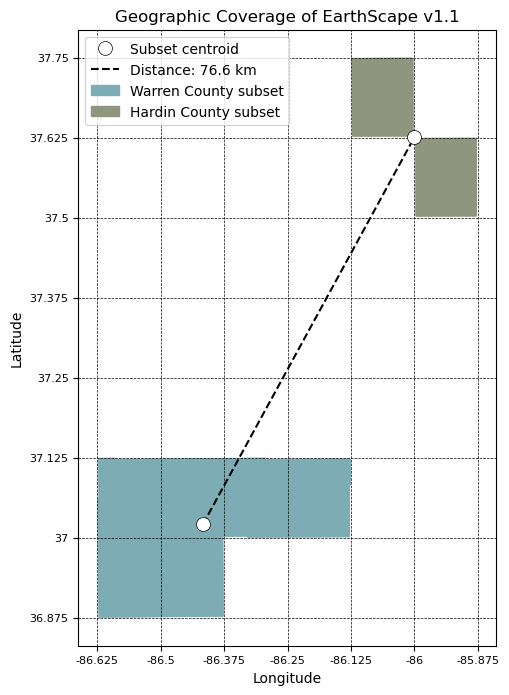

In [5]:
###################################
# Plot Dataset Patch Locations
###################################

# output path to save figure
output_path = os.path.join(ASSETS_DIR, f"{STR_VERSION}_map.png")


##### Calculate distance between Warren-Hardin County subsets (centroids)...
# read patches as gdf
gdf = gpd.read_file(patch_path)

# separate subsets into twwo gdf's
hardin_mask = (gdf['patch_id'].str.contains('hv')) | (gdf['patch_id'].str.contains('sonora'))
hardin = gdf[hardin_mask].copy()
warren = gdf[~hardin_mask]

# combine patches into single polygon & get centroids...
warren_centroid = warren.geometry.union_all().centroid
hardin_centroid = hardin.geometry.union_all().centroid

# compute distance between centroids (in native units -> US feet) & convert to km...
dist_ft = warren_centroid.distance(hardin_centroid)
dist_km = dist_ft * 0.0003048

# convert to lat-long WGS84...
warren = warren.to_crs(4326)
hardin = hardin.to_crs(4326)
warren_centroid = warren.geometry.union_all().centroid
hardin_centroid = hardin.geometry.union_all().centroid

##### Plot Subset Patches...
fig, ax = plt.subplots(figsize=(8,8))

# polygons...
warren.plot(ax=ax, color='#7EACB5', label='Warren County subset')
hardin.plot(ax=ax, color='#8E977D', label='Hardin County subset')

# centroids...
ax.scatter(warren_centroid.x, warren_centroid.y, s=100, edgecolor='k', facecolor='white', linewidth=0.5, zorder=4)
ax.scatter(hardin_centroid.x, hardin_centroid.y, s=100, edgecolor='k', facecolor='white', linewidth=0.5, zorder=4)

# connecting line...
ax.plot([warren_centroid.x, hardin_centroid.x], [warren_centroid.y, hardin_centroid.y], linestyle='--', color='k', zorder=3)

# legend...
w = Patch(color='#7EACB5', label='Warren County subset')
h = Patch(color='#8E977D', label='Hardin County subset')
c = Line2D([0], [0], marker='o', linestyle='none', markeredgecolor='k', markerfacecolor='white', markeredgewidth=0.5, markersize=10, label='Subset centroid')
l = Line2D([0], [0], linestyle='--', color='k', label=f"Distance: {dist_km:.1f} km")
ax.legend(handles=[c, l, w, h], loc='upper left', bbox_to_anchor=(0,1))

# setup grid and labels...
ax.set_xticks(np.arange(-86.625, -85.751, 0.125))
ax.set_xticklabels([f"{t:g}" for t in ax.get_xticks()], fontsize=8)
ax.set_xlabel('Longitude')
ax.set_yticks(np.arange(36.875, 37.751, 0.125))
ax.set_yticklabels([f"{t:g}" for t in ax.get_yticks()], fontsize=8)
ax.set_ylabel('Latitude')
ax.grid(True, linewidth=0.5, color='k', linestyle='--')

ax.set_title(f"Geographic Coverage of EarthScape v{VERSION}")

plt.savefig(output_path, dpi=500, bbox_inches='tight', pad_inches=0)
plt.show()

# **Modalities**

## *Warren County*

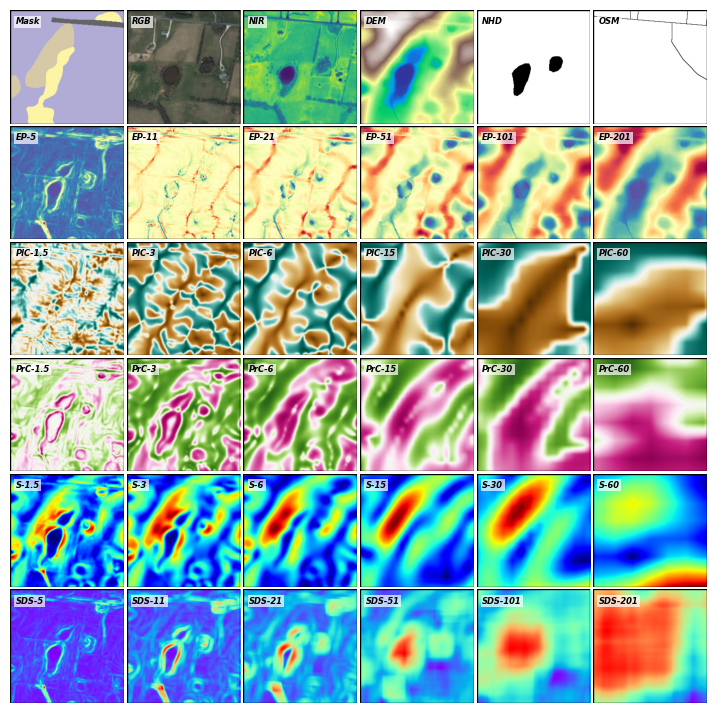

In [7]:
################################################
# Visualize Available EarthScape Modalities
################################################

# warren county example patch location...
patches_dir = os.path.abspath(os.path.join(DATASET_DIR, 'warren', 'patches'))
patch_id = '256_50_21983'

# define map class colors...
cmap = ListedColormap(list(SG_COLORS.values()))

# output path to save figure
output_path = os.path.join(ASSETS_DIR, 'warren_modalities.png')


##### plot modalities...
nrows = 6
ncols = 6
subplot_size = 1.5
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * subplot_size, nrows * subplot_size))
plt.subplots_adjust(hspace=0.02, wspace=0.02)
ax = ax.ravel()


# plot target mask...
with rasterio.open(f'{patches_dir}/{patch_id}_mask.tif') as src:
    show(src, ax=ax[0], cmap=cmap, vmin=1, vmax=7)


# plot rgb image (stacked)...
rgb = []
for image in [f"{patches_dir}/{patch_id}_aerialr.tif", f"{patches_dir}/{patch_id}_aerialg.tif", f"{patches_dir}/{patch_id}_aerialb.tif"]:
    with rasterio.open(image) as src:
        data = src.read(1)
        rgb.append(data)
rgb = np.dstack(rgb) / 255
ax[1].imshow(rgb)


# plot remaining features...
remaining = [
    'aerialnir.tif', 'dem.tif', 'nhd.tif', 'osm.tif',
    'sds_5x5.tif', 'ep_11x11.tif', 'ep_21x21.tif', 'ep_51x51.tif', 'ep_101x101.tif', 'ep_201x201.tif',
    'plc.tif', 'plc_10.tif', 'plc_20.tif', 'plc_50.tif', 'plc_100.tif', 'plc_200.tif',
    'prc.tif', 'prc_10.tif', 'prc_20.tif', 'prc_50.tif', 'prc_100.tif', 'prc_200.tif',
    's.tif', 's_10.tif', 's_20.tif', 's_50.tif', 's_100.tif', 's_200.tif',
    'sds_5x5.tif', 'sds_11x11.tif', 'sds_21x21.tif', 'sds_51x51.tif', 'sds_101x101.tif', 'sds_201x201.tif'
    ]

color_maps = [
    'viridis', 'terrain', 'binary', 'binary',
    'Spectral_r', 'Spectral_r', 'Spectral_r', 'Spectral_r', 'Spectral_r', 'Spectral_r',
    'BrBG', 'BrBG', 'BrBG', 'BrBG', 'BrBG', 'BrBG', 
    'PiYG', 'PiYG', 'PiYG', 'PiYG', 'PiYG', 'PiYG', 
    'jet', 'jet', 'jet', 'jet', 'jet', 'jet', 
    'rainbow', 'rainbow', 'rainbow', 'rainbow', 'rainbow', 'rainbow', 
    ]

for idx, (image, c) in enumerate(zip(remaining, color_maps), start=2):
    with rasterio.open(f"{patches_dir}/{patch_id}_{image}") as src:
        data = src.read(1)
        im = ax[idx].imshow(data, cmap=c)


# plot annotation labels...
for idx, label in enumerate([
    'Mask', 'RGB', 'NIR', 'DEM', 'NHD', 'OSM', 
    'EP-5', 'EP-11', 'EP-21', 'EP-51', 'EP-101', 'EP-201',
    'PlC-1.5', 'PlC-3', 'PlC-6', 'PlC-15', 'PlC-30', 'PlC-60', 
    'PrC-1.5', 'PrC-3', 'PrC-6', 'PrC-15', 'PrC-30', 'PrC-60', 
    'S-1.5', 'S-3', 'S-6', 'S-15', 'S-30', 'S-60', 
    'SDS-5', 'SDS-11', 'SDS-21', 'SDS-51', 'SDS-101', 'SDS-201', 
    ], 
    start=0):

    ax[idx].set_title(label, style='italic', weight='bold', size=6, y=0.8, x=0.05, loc='left', bbox=dict(facecolor='white', edgecolor='none', pad=1.0, alpha=0.7))



# remove axes & add image boundary lines...
for axis in ax:
    axis.set_axis_off()
    rect = Rectangle((0, 0), 1, 1, transform=axis.transAxes, linewidth=1, edgecolor='k', facecolor='none')
    axis.add_patch(rect)

plt.savefig(output_path, dpi=500, bbox_inches='tight', pad_inches=0)
plt.show()

## *Hardin County*

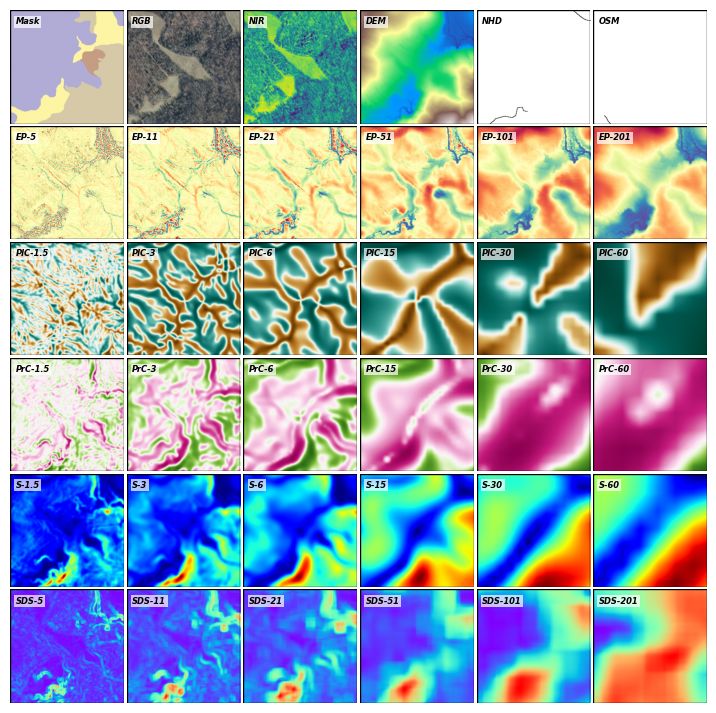

In [8]:
################################################
# Visualize Available EarthScape Modalities
################################################

# warren county example patch location...
patches_dir = os.path.abspath(os.path.join(DATASET_DIR, 'howevalley', 'patches'))
patch_id = 'hv_256_50_548'

# define map class colors...
cmap = ListedColormap(list(SG_COLORS.values()))

# output path to save figure
output_path = os.path.join(ASSETS_DIR, 'hardin_modalities.png')


##### plot modalities...
nrows = 6
ncols = 6
subplot_size = 1.5
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * subplot_size, nrows * subplot_size))
plt.subplots_adjust(hspace=0.02, wspace=0.02)
ax = ax.ravel()


# plot target mask...
with rasterio.open(f"{patches_dir}/{patch_id}_mask.tif") as src:
    show(src, ax=ax[0], cmap=cmap, vmin=1, vmax=7)


# plot rgb image (stacked)...
rgb = []
for image in [f"{patches_dir}/{patch_id}_aerialr.tif", f"{patches_dir}/{patch_id}_aerialg.tif", f"{patches_dir}/{patch_id}_aerialb.tif"]:
    with rasterio.open(image) as src:
        data = src.read(1)
        rgb.append(data)
rgb = np.dstack(rgb) / 255
ax[1].imshow(rgb)


# plot remaining features...
remaining = [
    'aerialnir.tif', 'dem.tif', 'nhd.tif', 'osm.tif',
    'ep_5x5.tif', 'ep_11x11.tif', 'ep_21x21.tif', 'ep_51x51.tif', 'ep_101x101.tif', 'ep_201x201.tif',
    'plc.tif', 'plc_10.tif', 'plc_20.tif', 'plc_50.tif', 'plc_100.tif', 'plc_200.tif',
    'prc.tif', 'prc_10.tif', 'prc_20.tif', 'prc_50.tif', 'prc_100.tif', 'prc_200.tif',
    's.tif', 's_10.tif', 's_20.tif', 's_50.tif', 's_100.tif', 's_200.tif',
    'sds_5x5.tif', 'sds_11x11.tif', 'sds_21x21.tif', 'sds_51x51.tif', 'sds_101x101.tif', 'sds_201x201.tif'
    ]

color_maps = [
    'viridis', 'terrain', 'binary', 'binary',
    'Spectral_r', 'Spectral_r', 'Spectral_r', 'Spectral_r', 'Spectral_r', 'Spectral_r',
    'BrBG', 'BrBG', 'BrBG', 'BrBG', 'BrBG', 'BrBG', 
    'PiYG', 'PiYG', 'PiYG', 'PiYG', 'PiYG', 'PiYG', 
    'jet', 'jet', 'jet', 'jet', 'jet', 'jet', 
    'rainbow', 'rainbow', 'rainbow', 'rainbow', 'rainbow', 'rainbow', 
    ]

for idx, (image, c) in enumerate(zip(remaining, color_maps), start=2):
    with rasterio.open(f"{patches_dir}/{patch_id}_{image}") as src:
        data = src.read(1)
        im = ax[idx].imshow(data, cmap=c)


# plot annotation labels...
for idx, label in enumerate([
    'Mask', 'RGB', 'NIR', 'DEM', 'NHD', 'OSM', 
    'EP-5', 'EP-11', 'EP-21', 'EP-51', 'EP-101', 'EP-201',
    'PlC-1.5', 'PlC-3', 'PlC-6', 'PlC-15', 'PlC-30', 'PlC-60', 
    'PrC-1.5', 'PrC-3', 'PrC-6', 'PrC-15', 'PrC-30', 'PrC-60', 
    'S-1.5', 'S-3', 'S-6', 'S-15', 'S-30', 'S-60', 
    'SDS-5', 'SDS-11', 'SDS-21', 'SDS-51', 'SDS-101', 'SDS-201', 
    ], 
    start=0):

    ax[idx].set_title(label, style='italic', weight='bold', size=6, y=0.8, x=0.05, loc='left', bbox=dict(facecolor='white', edgecolor='none', pad=1.0, alpha=0.7))



# remove axes & add image boundary lines...
for axis in ax:
    axis.set_axis_off()
    rect = Rectangle((0, 0), 1, 1, transform=axis.transAxes, linewidth=1, edgecolor='k', facecolor='none')
    axis.add_patch(rect)

plt.savefig(output_path, dpi=500, bbox_inches='tight', pad_inches=0)
plt.show()

# **Class Frequency**

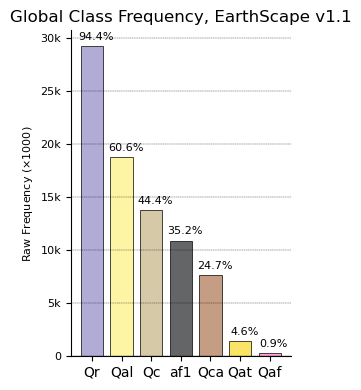

In [ ]:
##################################################
# Global Dataset Class Frequency Plot
##################################################

# output path to save figure
output_path = os.path.join(ASSETS_DIR, f"{STR_VERSION}_class_freq.png")


##### calculate class presence counts...
areas = pd.read_csv(areas_path)                            # df of class-area proportion per patch
class_counts = (areas[areas.columns[1:]] > 0).sum()        # number of patches with class presence (at least 1 pixel or more)
class_counts = class_counts.sort_values(ascending=False)   # order bar plots by descending frequency
class_labels = class_counts.index

##### plot class frequency...
fig, ax = plt.subplots(figsize=(3,4))

# plot bars...
bars = ax.bar(x=class_labels, height=class_counts, edgecolor='k', linewidth=0.5, facecolor=[SG_COLORS[c] for c in class_labels], width=0.75)

# plot annotations of class presence in dataset...
percentages = class_counts / len(areas) * 100
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    ax.annotate(f"{pct:.1f}%", xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(3, 3), textcoords='offset points', ha='center', va='bottom', fontsize=8)
    
# customize x axis...
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), fontsize=10)

# customize y axis
ax.set_yticks(range(0,30001, 5000))
ax.set_yticklabels(['0', '5k', '10k', '15k', '20k', '25k', '30k'], fontsize=8)
ax.set_ylabel(r'Raw Frequency ($\times 1000$)', fontsize=8)

# customize plot...
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='k', linestyle='--', linewidth=0.25)
ax.set_title(f"Global Class Frequency, EarthScape v{VERSION}")

plt.savefig(output_path, dpi=500, bbox_inches='tight', pad_inches=0)
plt.tight_layout()
plt.show()



# **Class Area**

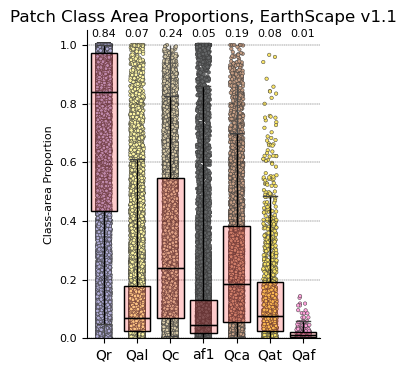

In [ ]:
##################################################
# Global Dataset Class-area Proportion Plot
##################################################

# output path to save figure
output_path = os.path.join(ASSETS_DIR, f"{STR_VERSION}_class_area.png")


##### pre-process data...
areas = pd.read_csv(areas_path)
class_labels = areas.columns[1:]

# convert to long format -> each patch has 1:K rows for class k & corresponding area (patch_id, class k, area proportion)
long = areas.melt(id_vars=['patch_id'], value_vars=class_labels, var_name='class', value_name='area')

# keep only rows with class presence
long = long[long['area'] > 0].copy()

# get order of classes by median patch area proportion
order = long.groupby('class')['area'].median().sort_values(ascending=False).index

# order plots by descending frequency class count frequency (same as frequency plot)...
class_labels = (areas[areas.columns[1:]] > 0).sum()        # number of patches with class presence (at least 1 pixel or more)
class_labels = class_labels.sort_values(ascending=False)   # order bar plots by descending frequency
order = class_labels.index                                 # class labels in descending order


##### plot class-area proportions...
fig, ax = plt.subplots(figsize=(3,4))

# strip plot of class areas with jitter (ordered by descending class frequency)
sns.stripplot(data=long, x='class', y='area', jitter=0.2, size=2.5, order=order, hue='class', palette=SG_COLORS, linewidth=0.35, ax=ax, zorder=1)

# filled boxplot with alpha over strip plot
sns.boxplot(data=long, x='class', y='area', showcaps=False, showfliers=False,
            boxprops={'facecolor': 'red', 'alpha':0.2},
            order=order, ax=ax, zorder=2)

# hollow boxplot on top
sns.boxplot(data=long, x='class', y='area', showcaps=True, showfliers=False, whis=(5, 95), 
            boxprops={'facecolor': 'none', 'edgecolor': 'k', 'linewidth': 1}, 
            whiskerprops={'linewidth': 1, 'color': 'k'}, capprops={'linewidth': 1},
            medianprops={'color': 'k', 'linewidth': 1},
            order=order, ax=ax, zorder=3)

# annotate median class-area proportions at top...
top_y = 1.02
x_positions = ax.get_xticks()
medians = long.groupby('class')['area'].median()

for x, cls in zip(x_positions, order):
    m = medians[cls]
    ax.annotate(f"{m:.2f}", xy=(x, top_y), ha="center", va="bottom", fontsize=8)

# customize x axis...
ax.set_xlabel('')
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), fontsize=10)

# customize y axis...
ax.set_ylim(0, 1.05)
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
ax.set_ylabel(r'Class-area Proportion', fontsize=8)
ax.set_title(f"Patch Class Area Proportions, EarthScape v{VERSION}")

# customize plot...
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='k', linestyle='--', linewidth=0.25)

plt.savefig(output_path, dpi=500, bbox_inches='tight', pad_inches=0)
plt.show()


# **Spatial Class Distribution**

## *Geographic Imbalance Map*

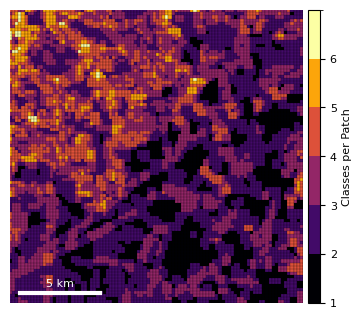

In [ ]:
##################################################
# Class Frequency Choropleth Map of Example Area
##################################################

# example map area coordinates (in EPSG:3089 coordinates)
x_coords = (4.67e6, 4.73e6)
y_coords = (3.48e6, 3.54e6)

# output path to save figure
output_path = os.path.join(ASSETS_DIR, 'spatial_imbalance_map.png')


##### pre-processing...
gdf = gpd.read_file(patch_path)
areas = pd.read_csv(areas_path)

# get class presence (1 pixel or more is present)
areas['total_classes'] = (areas[areas.columns[1:]] > 0).sum(axis=1)

# merge with patches GeoJSON
gdf_areas = gdf.merge(areas, on='patch_id')


##### plot class frequency choropleth map...
fig, ax = plt.subplots(figsize=(4,4))

# discrete colormap for integer total_classes...
values = gdf_areas['total_classes']
classes = sorted(values.unique())
cmap = mpl.cm.inferno
cmap_bounds = np.arange(min(classes), max(classes) + 2)
norm = mpl.colors.BoundaryNorm(cmap_bounds, cmap.N)

# plot choropleth map
gdf_areas.plot(column='total_classes', cmap=cmap, norm=norm, linewidth=0.15, edgecolor='k', ax=ax)

# adjust map area to example area coordinates...
ax.set_xlim(x_coords)
ax.set_ylim(y_coords)
ax.set_axis_off()

# add colorbar to the right axis with same height...
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.05)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax, boundaries=cmap_bounds, ticks=classes)
cbar.set_label('Classes per Patch', fontsize=8)
cbar.set_ticklabels([1, 2, 3, 4, 5, 6], fontsize=8)

# add 5 km scale bar...
# NOTE: EPSG:3089 has units of feet -> 5 km = 5000 m = 5000 / 0.3048 = 16404.2 ft
scale_length_ft = 16404.2
x0 = x_coords[0] + 2000 
y0 = y_coords[0] + 2000
ax.plot([x0, x0 + scale_length_ft], [y0, y0], color='white', linewidth=3)
ax.text(x0 + scale_length_ft/2, y0 + 1000, '5 km', color='white', ha='center', va='bottom', fontsize=8)

plt.savefig(output_path, dpi=500, bbox_inches='tight', pad_inches=0)
plt.show()


## *Patch Class Frequency Histogram*

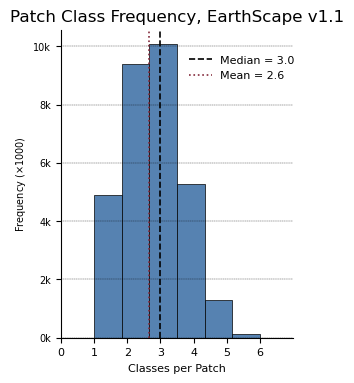

In [ ]:
##################################################
# Histogram of Class Frequency per Patch
##################################################

# output path to save figure
output_path = os.path.join(ASSETS_DIR, 'patch_freq.png')


##### pre-processing...
areas = pd.read_csv(areas_path)
total_classes = (areas[areas.columns[1:]] > 0).sum(axis=1)

##### plot histogram...
fig, ax = plt.subplots(figsize=(3,4))
ax.hist(total_classes, bins=6, align='mid', linewidth=0.5, edgecolor='k', facecolor='#5682B1')

# plot median & mean frequencies...
median_val = np.median(total_classes)
mean_val = np.mean(total_classes)
ax.axvline(median_val, color='k', linestyle='--', linewidth=1.2, label=f"Median = {median_val:.1f}")
ax.axvline(mean_val, color='#842A3B', linestyle=':', linewidth=1.2, label=f"Mean = {mean_val:.1f}")

# add legend
leg = ax.legend(frameon=False, loc='upper right', bbox_to_anchor=(1.05, 0.95), fontsize=8)

# adjust x axis...
ax.set_xlim(0, len(areas.columns[1:]))
ax.set_xticks(range(len(areas.columns[1:])))
ax.set_xticklabels([str(c) for c in range(len(areas.columns[1:]))], fontsize=8)
ax.set_xlabel('Classes per Patch', fontsize=8)

# adjust y axis...
ax.set_yticks(np.arange(0, 10200, 2000))
ax.set_yticklabels([str(int(i/1000))+'k' for i in np.arange(0,10200, 2000)], fontsize=7)
ax.set_ylabel(r'Frequency ($\times1000$)', fontsize=7)
ax.set_title(f"Patch Class Frequency, EarthScape v{VERSION}")

# customize plot...
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='k', linestyle='--', linewidth=0.25)

plt.savefig(output_path, dpi=500, bbox_inches='tight', pad_inches=0)
plt.show()

## *Class Co-occurrence*

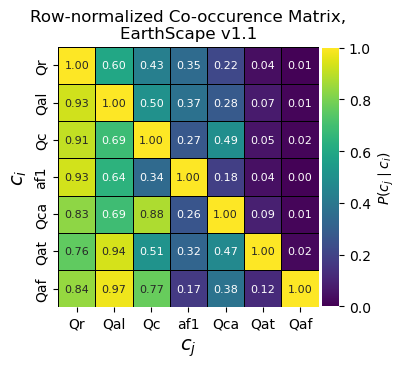

In [ ]:
##################################################
# Class Co-occurrence Matrix
##################################################

# output path to save figure
output_path = os.path.join(ASSETS_DIR, 'co-occurrence.png')


##### pre-processing...
areas = pd.read_csv(areas_path)
presence = (areas[areas.columns[1:]] > 0).astype(int)        # binary class presence (at least 1 pixel or more)
order = presence.sum().sort_values(ascending=False)          # get total class counts sorted in descending frequency
presence = presence[order.index]                             # reorder columns by order
co_matrix = presence.T @ presence                            # co-occurence matrix of raw counts
co_norm = co_matrix.div(np.diag(co_matrix), axis=0)          # normalized matrix -> P(c_j | c_i)


##### plot heatmap...
fig, ax = plt.subplots(figsize=(4,4))

# plot heatmap with colorbar...
sns.heatmap(co_norm, vmin=0, vmax=1, cmap='viridis', square=True, ax=ax,
            linewidths=0.5, linecolor='k', 
            annot=True, fmt=".2f", annot_kws={'fontsize': 8}, 
            cbar=True, 
            cbar_kws={'label': r'$P(c_j \mid c_i)$', 'shrink': 0.84, 'aspect':15, 'pad': 0.01, })

# set axis labels...
ax.set_xlabel(r"$c_j$", fontsize=14)
ax.set_ylabel(r"$c_i$", fontsize=14)
ax.set_title(f"Row-normalized Co-occurence Matrix,\nEarthScape v{VERSION}")

plt.savefig(output_path, dpi=500, bbox_inches='tight', pad_inches=0)
plt.show()


# **Dataset Statistics**

## *Imbalance Metrics*

In [ ]:
##################################################
# Class Imbalance Metrics
##################################################

# output path to save figure
output_path = os.path.join(ASSETS_DIR, 'imbalance_metrics.csv')


##### pre-processing...
areas = pd.read_csv(areas_path)
class_cols = areas.columns[1:]


##### per class count metrics...
# basic counts & percentages of patches containing each class...
class_counts = (areas[class_cols] > 0).sum()
class_per = class_counts / len(areas) * 100

# imbalance ratio per label (IRLbl)...
max_count = class_counts.max()
irlbl = max_count / class_counts

# effective number of samples (Cui et al., 2019)...
beta = 0.9999
n_eff = (1 - beta ** class_counts) / (1 - beta)


##### per class area metrics...
# mean and sd of class area proportions...
mean_area = areas[class_cols].mean(axis=0)
sd_area = areas[class_cols].std(axis=0)

# per class patch-level dominance...
majority_class = areas[class_cols].idxmax(axis=1)
dominant_rate = majority_class.value_counts(normalize=True)


##### dataset-level metrics...
# total samples
total_samples = len(areas)

# majority area rate (MAR)
mar = mean_area.max()

# entropy (distribution diversity)
p = mean_area / mean_area.sum()
entropy = -(p * np.log(p)).sum()
entropy_norm = entropy / np.log(len(p))

# gini coefficient (inequality)
x = np.sort(np.asarray(mean_area))
n = len(x)
gini = (2*np.sum((np.arange(1,n+1)*x))) / (n*np.sum(x)) - (n+1)/n


##### construct dataframe...
# per class metrics...
stats = pd.DataFrame({
    'Frequency (n)': class_counts,
    'Frequency (%)': class_per,
    'IRLbl': irlbl,
    'N_eff': n_eff,
    'Mean Area': mean_area,
    'SD Area': sd_area,
    'Dominant Rate': dominant_rate,
    })
stats.fillna(0, inplace=True)
stats.sort_values('Frequency (n)', ascending=False, inplace=True)

# dataset metrics...
ds_stats = pd.DataFrame({
    'Total Samples': total_samples,
    'Entropy (norm.)': entropy_norm,
    'Gini Coef.': gini
    }, index=[f"ES v{VERSION}"])

# merge dfs...
df = pd.concat([stats, ds_stats])
df.to_csv(output_path)
df.head(10)

,Frequency (n),Frequency (%),IRLbl,N_eff,Mean Area,SD Area,Dominant Rate,Total Samples,Entropy (norm.),Gini Coef.
Qr,29271.0,94.367786,1.000000,9464.557233,0.650765,0.358058,0.701496,NaN,NaN,NaN
Qal,18802.0,60.616416,1.556802,8474.547516,0.089023,0.167953,0.058385,NaN,NaN,NaN
Qc,13768.0,44.387130,2.126017,7476.324808,0.141715,0.242290,0.148075,NaN,NaN,NaN
af1,10908.0,35.166677,2.683443,6640.706952,0.050993,0.160891,0.034625,NaN,NaN,NaN
Qca,7666.0,24.714682,3.818289,5354.278166,0.060953,0.154080,0.053679,NaN,NaN,NaN
Qat,1435.0,4.626346,20.397909,1336.854161,0.006383,0.045366,0.003740,NaN,NaN,NaN
Qaf,270.0,0.870462,108.411111,266.400726,0.000168,0.002835,0.000000,NaN,NaN,NaN
ES v1.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31018.0,0.579581,0.645853


## *Maximum Mean Discrepancy*

In [ ]:
##################################################
# MMD of Raw Input Features
##################################################

# directory paths for warren & hardin data subsets...
warren_dirs = [os.path.join(DATASET_DIR, 'warren')]
hardin_dirs = [os.path.join(DATASET_DIR, 'howevalley'), 
               os.path.join(DATASET_DIR, 'sonora')]

# data directory paths...
warren_data_dirs = [os.path.join(d, 'patches') for d in warren_dirs]
hardin_data_dirs = [os.path.join(d, 'patches') for d in hardin_dirs]

# feature vector of percentiles describing distribution
percentiles = [5, 10, 25, 50, 75, 90, 95]

# number of samples to randomly select from each area
size = 1000

# number of runs to calculate MMD standard deviation & CIs
runs = 50

# set seed & rng for sampling
seed = 111
rng = np.random.default_rng(seed)

# input features for MMD calculations...
in_features = {

    # single modalities...
    'DEM': ['dem.tif'], 
    'RGB': ['aerialr.tif', 'aerialg.tif', 'aerialb.tif'],
    'RGB+NIR': ['aerialr.tif', 'aerialg.tif', 'aerialb.tif', 'aerialnir.tif'],
    'NHD': ['nhd.tif'],
    'OSM': ['osm.tif'],
    'EP 5': ['ep_5x5.tif'], 'EP 11': ['ep_11x11.tif'], 'EP 21': ['ep_21x21.tif'], 'EP 51': ['ep_51x51.tif'], 'EP 101': ['ep_101x101.tif'], 'EP 201': ['ep_201x201.tif'],
    'PlC 5': ['plc.tif'], 'PlC 10': ['plc_10.tif'], 'PlC 20': ['plc_20.tif'], 'PlC 50': ['plc_50.tif'], 'PlC 100': ['plc_100.tif'], 'PlC 200': ['plc_200.tif'],
    'PrC 5': ['prc.tif'], 'PrC 10': ['prc_10.tif'], 'PrC 20': ['prc_20.tif'], 'PrC 50': ['prc_50.tif'], 'PrC 100': ['prc_100.tif'], 'PrC 200': ['prc_200.tif'],
    'S 5': ['s.tif'], 'S 10': ['s_10.tif'], 'S 20': ['s_20.tif'], 'S 50': ['s_50.tif'], 'S 100': ['s_100.tif'], 'S 200': ['s_200.tif'],
    'SDS 5': ['sds_5x5.tif'], 'SDS 11': ['sds_11x11.tif'], 'SDS 21': ['sds_21x21.tif'], 'SDS 51': ['sds_51x51.tif'], 'SDS 101': ['sds_101x101.tif'], 'SDS 201': ['sds_201x201.tif'],

    # multi-scale single modalities...
    'EP ms': ['ep_5x5.tif', 'ep_11x11.tif', 'ep_21x21.tif', 'ep_51x51.tif', 'ep_101x101.tif', 'ep_201x201.tif'],
    'PlC ms': ['plc.tif', 'plc_10.tif', 'plc_20.tif', 'plc_50.tif', 'plc_100.tif', 'plc_200.tif'],
    'PrC ms': ['prc.tif', 'prc_10.tif', 'prc_20.tif', 'prc_50.tif', 'prc_100.tif', 'prc_200.tif'],
    'S ms': ['s.tif', 's_10.tif', 's_20.tif', 's_50.tif', 's_100.tif', 's_200.tif'],
    'SDS ms': ['sds_5x5.tif', 'sds_11x11.tif', 'sds_21x21.tif', 'sds_51x51.tif', 'sds_101x101.tif', 'sds_201x201.tif'],
    
    # # multimodal...
    # 'DEM+RGB': ['dem.tif', 'aerialr.tif', 'aerialg.tif', 'aerialb.tif'],
    # 'S 5+DEM': ['s.tif', 'dem.tif'],
    # 'S 200+OSM': [],
    # 'S ms+DEM': ['s.tif', 's_10.tif', 's_20.tif', 's_50.tif', 's_100.tif', 's_200.tif', 'dem.tif'],
    # 'S+SDS': ['s.tif', 's_10.tif', 's_20.tif', 's_50.tif', 's_100.tif', 's_200.tif', 
    #           'sds_5x5.tif', 'sds_11x11.tif', 'sds_21x21.tif', 'sds_51x51.tif', 'sds_101x101.tif', 'sds_201x201.tif'],
    # 'DEM+S+SDS': ['s.tif', 's_10.tif', 's_20.tif', 's_50.tif', 's_100.tif', 's_200.tif', 
    #               'sds_5x5.tif', 'sds_11x11.tif', 'sds_21x21.tif', 'sds_51x51.tif', 'sds_101x101.tif', 'sds_201x201.tif', 'dem.tif'],
    }


##### select kernel gamma parameter...
# NOTE: this fixes the gamma for comparability
gamma_dict = {}
for name, features in in_features.items():
    warren_ids = select_samples(warren_dirs, size=size, rng=rng)
    hardin_ids = select_samples(hardin_dirs, size=size, rng=rng)
    _, _, gamma = compute_mmd(warren_data_dirs, hardin_data_dirs, warren_ids, hardin_ids, in_features=features, gamma=None, percentiles=percentiles)
    gamma_dict[name] = gamma


##### compute MMD across multiple samples with fixed parameters...
results = []
for run in range(runs):

    # select samples & fix for MMD calculations of each modality input...
    warren_ids = select_samples(warren_dirs, size=size, rng=rng)
    hardin_ids = select_samples(hardin_dirs, size=size, rng=rng)

    # calculate mmd & save results...
    for name, features in in_features.items():
        mmd, pval, gamma_new = compute_mmd(warren_data_dirs, hardin_data_dirs, warren_ids, hardin_ids, in_features=features, gamma=gamma, percentiles=percentiles)
        results.append({
            'Run': run,                 # run number (repeated 'runs' times for each modality)
            'Feature': name,            # modality input or multiple inputs
            'gamma (fixed)': gamma,     # fixed gamma used in all tests
            'gamma (run)': gamma_new,   # new gamma calculated during each test (assess stability with fixed gamma)
            'MMD2': mmd,                # MMD^2 statistics
            'MMD': np.sqrt(mmd),        # MMD value (euclidean distance)
            'p-value': pval,            # p-value of MMD^2 permutation test (n=1000)
        })
    
# convert to df & save results...
df_results = pd.DataFrame(results)
# df_results = pd.to_csv(output_path, index=False)

##### calculate summary results for all runs/tests including confidence intervals...
df_summary = (df_results.groupby('Feature').agg(**{
    'Runs': ('Run', 'count'),                         # number of runs
    'gamma (mu)': ('gamma (run)', 'mean'),            # mean of gammas calculated during each run
    'gamma (sd)': ('gamma (run)', 'std'),             # sd of gammas
    'MMD (mu)': ('MMD', 'mean'),                      # mean MMD value
    'MMD (sd)': ('MMD', 'std'),                       # SD MMD
    'p-value (mu)': ('p-value', 'mean')               # mean of p-values
    }).reset_index())

# standard error
df_summary['SE'] = df_summary['MMD (sd)'] / np.sqrt(df_summary['Runs'])

# t-distribution critical value
df_summary['tcrit'] = df_summary['Runs'].apply(lambda n: t.ppf(0.975, df=n-1))

# 95% confidence interval
df_summary['CI95'] = df_summary['tcrit'] * df_summary['SE']

# relative shift (normalized to largest MMD value)
df_summary['Rel Shift'] = df_summary['MMD (mu)'] / df_summary['MMD (mu)'].max()

# save summary
df_summary.to_csv(output_path, index=False)

df_summary.head(10)

,Feature,Runs,gamma (mu),gamma (sd),MMD (mu),MMD (sd),p-value (mu),SE,tcrit,CI95,Rel Shift
0,RGB,50,0.021625,0.000266,0.139619,0.005091,7.503958e-60,0.000720,2.009575,0.001447,0.503417
1,RGB+NIR,50,0.013371,0.000095,0.212073,0.002554,1.101788e-151,0.000361,2.009575,0.000726,0.764662
2,DEM,50,0.072195,0.000750,0.277342,0.002838,3.928623e-262,0.000401,2.009575,0.000806,1.000000
3,NHD,50,0.013894,0.001220,0.036711,0.006068,7.285772e-04,0.000858,2.009575,0.001725,0.132367
4,OSM,50,0.003267,0.000880,0.027710,0.004068,1.156797e-03,0.000575,2.009575,0.001156,0.099914
5,EP 5,50,0.102950,0.009845,0.062490,0.005580,4.618923e-11,0.000789,2.009575,0.001586,0.225318
6,EP 11,50,0.092569,0.014302,0.047859,0.004897,5.064454e-08,0.000693,2.009575,0.001392,0.172562
7,EP 21,50,0.073864,0.008039,0.071750,0.006363,7.445035e-16,0.000900,2.009575,0.001808,0.258705
8,EP 51,50,0.058404,0.003801,0.098850,0.006200,3.476558e-29,0.000877,2.009575,0.001762,0.356419
9,EP 101,50,0.051099,0.001374,0.092492,0.006304,4.378504e-26,0.000891,2.009575,0.001791,0.333493


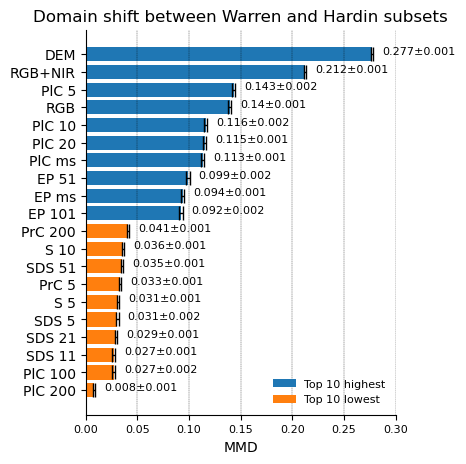

In [19]:
##################################################
# Bar Chart of MMD Results
##################################################

# path to MMD summary
summary_path = os.path.join(ASSETS_DIR, 'mmd_summary.csv')

# define number of comparisons of highest & lowest N
n_comparison = 10

# output path to save figure
output_path = os.path.join(ASSETS_DIR, 'mmd_bar.png')


# ##### pre-processing...
df = pd.read_csv(summary_path)
df = df.sort_values("Rel Shift", ascending=False)
df = df[~((df['Feature'] == 'OSM') | (df['Feature'] == 'NHD'))].reset_index(drop=True)

# use top N highest & lowest MMD values for plot...
df_hi = df.loc[df.index[:n_comparison]]
df_lo = df.loc[df.index[-n_comparison:]]


##### plot comparative bar chart...
fig, ax = plt.subplots(figsize=(4,n_comparison/2))

ax.barh(df_hi['Feature'], df_hi['MMD (mu)'], xerr=df_hi['CI95'], label='Top 10 highest', error_kw={'capsize': 5, 'linewidth': 1})
ax.barh(df_lo['Feature'], df_lo['MMD (mu)'], xerr=df_lo['CI95'], label='Top 10 lowest', error_kw={'capsize': 5, 'linewidth': 1})

# plot mean & CI next to bars...
for _,row in df_hi.iterrows():
    y = row['Feature']
    x = row['MMD (mu)']
    ci = row['CI95']
    label = f"{round(x,3)}\u00b1{round(ci,3)}"
    ax.text(x=x+0.01, y=y, s=label, fontsize=8)

for _,row in df_lo.iterrows():
    y = row['Feature']
    x = row['MMD (mu)']
    ci = row['CI95']
    label = f"{round(x,3)}\u00b1{round(ci,3)}"
    ax.text(x=x+0.01, y=y, s=label, fontsize=8)

# customize plot...
ax.legend(loc='lower right', bbox_to_anchor=(1,0), frameon=False, fontsize=8)
ax.set_xticks(np.arange(0, df_hi['MMD (mu)'].max()+0.05, 0.05))
ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)
plt.gca().invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', color='k', linestyle='--', linewidth=0.25)
ax.set_xlabel('MMD')
plt.title('Domain shift between Warren and Hardin subsets')

plt.savefig(output_path, dpi=500, bbox_inches='tight', pad_inches=0)
plt.show()